# Lab Experiment 8 - KNN Classifier
**Subject:** Machine Learning Theory and Practice | **Code:** E1CAB 613

**Dataset:** Banknote Authentication

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

## Task 1: Exploratory Data Analysis (EDA)

In [23]:
# Load Banknote Authentication dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
cols = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df = pd.read_csv(url, header=None, names=cols)

print('Dataset Shape:', df.shape)
print('\nClass Distribution:')
print(df['class'].value_counts())
df.head()

Dataset Shape: (1372, 5)

Class Distribution:
class
0    762
1    610
Name: count, dtype: int64


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


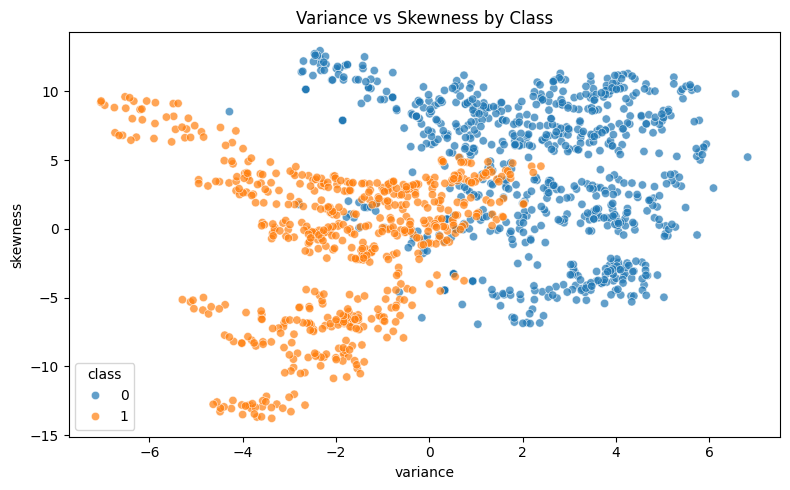

In [24]:
# Visualize relationship between two numerical columns
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='variance', y='skewness', hue='class', alpha=0.7)
plt.title('Variance vs Skewness by Class')
plt.tight_layout()
plt.show()

## Task 2: Data Cleaning & Transformation

In [25]:
# Clean and scale features for KNN
print('Missing values per column:')
print(df.isnull().sum())

df = df.drop_duplicates()

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\nTraining shape:', X_train_scaled.shape)
print('Testing shape:', X_test_scaled.shape)

Missing values per column:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Training shape: (1078, 4)
Testing shape: (270, 4)


## Task 3: Optimal K Selection (Elbow Method)

Optimal K: 3
Minimum Error Rate: 0.0


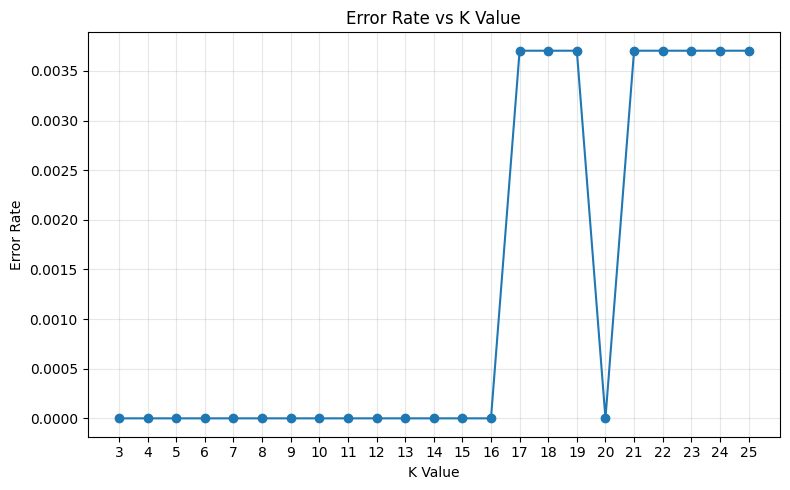

In [26]:
error_rates = []
k_values = range(3, 26)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    error_rates.append(np.mean(y_pred_k != y_test))

optimal_k = list(k_values)[int(np.argmin(error_rates))]
print('Optimal K:', optimal_k)
print('Minimum Error Rate:', min(error_rates))

plt.figure(figsize=(8, 5))
plt.plot(k_values, error_rates, marker='o')
plt.title('Error Rate vs K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Task 4: Final KNN Model

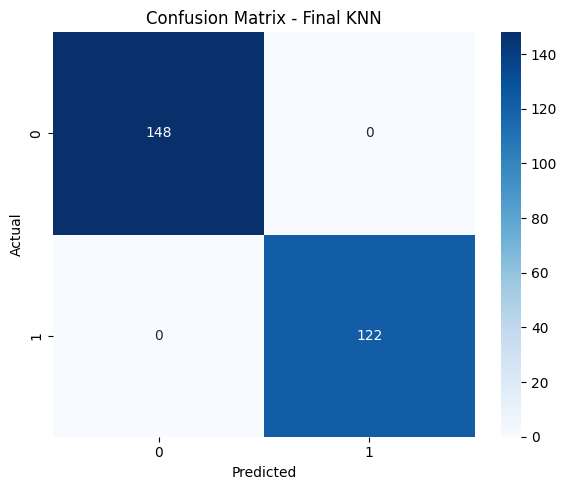

TN=148, FP=0, FN=0, TP=122
Off-diagonal zeros are correct here: the model made no mistakes on this test split.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       122

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



In [27]:
final_knn = KNeighborsClassifier(n_neighbors=optimal_k, weights='distance')
final_knn.fit(X_train_scaled, y_train)
y_pred = final_knn.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title('Confusion Matrix - Final KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')
if fp == 0 and fn == 0:
    print('Off-diagonal zeros are correct here: the model made no mistakes on this test split.')

print('\nClassification Report:')
print(classification_report(y_test, y_pred))